In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import kagglehub
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)
print(path)

C:\Users\adith\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [3]:
train_data = tf.keras.utils.image_dataset_from_directory(
    path + '/chest_xray/train',
    image_size=(224, 224),
    batch_size=32
)

Found 5216 files belonging to 2 classes.


In [4]:
test_data=tf.keras.utils.image_dataset_from_directory(
    path +'/chest_xray/test',
    image_size=(224,224),
    batch_size=32
)

Found 624 files belonging to 2 classes.


In [5]:
val_data=tf.keras.utils.image_dataset_from_directory(
    path +'/chest_xray/val',
    image_size=(224,224),
    batch_size=32
)

Found 16 files belonging to 2 classes.


In [6]:
class_names=train_data.class_names
print(class_names)

['NORMAL', 'PNEUMONIA']


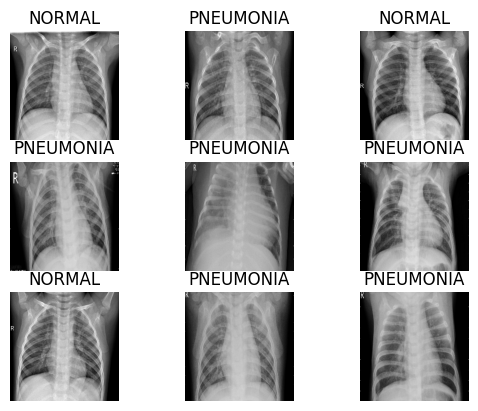

In [7]:
import matplotlib.pyplot as plt
for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [8]:
normalization_layer = layers.Rescaling(1./255)

In [9]:
train_data=train_data.map(
    lambda x,y:(normalization_layer(x),y)
)

In [10]:
test_data=test_data.map(
    lambda x,y:(normalization_layer(x),y)
)

In [11]:
value_data=val_data.map(
    lambda x,y:(normalization_layer(x),y)
)

In [12]:
cnn = models.Sequential([   
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(224, 224, 3)
    ),
    layers.MaxPooling2D((2, 2)), 
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

C:\Users\adith\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history=cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.9005 - loss: 0.2576 - val_accuracy: 0.9375 - val_loss: 1.7000
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.9555 - loss: 0.1213 - val_accuracy: 0.6875 - val_loss: 97.1567
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.9741 - loss: 0.0701 - val_accuracy: 0.8125 - val_loss: 52.7816
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.9776 - loss: 0.0624 - val_accuracy: 0.8750 - val_loss: 41.3993
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.9845 - loss: 0.0399 - val_accuracy: 0.8125 - val_loss: 114.8826


In [16]:
cnn.evaluate(test_data)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 497ms/step - accuracy: 0.6843 - loss: 2.5196


[2.5195541381835938, 0.6842948794364929]

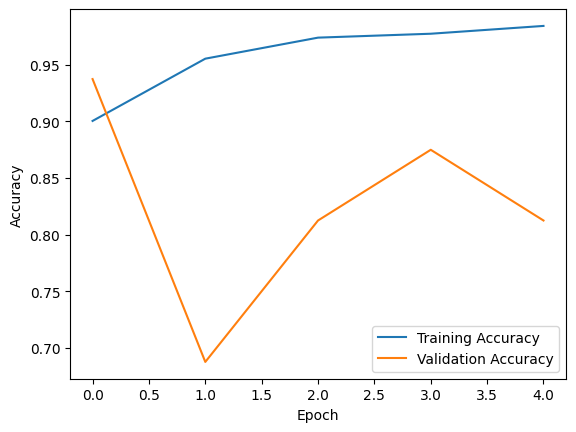

In [17]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [18]:
y_predict = cnn.predict(test_data)

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step


In [19]:
loss,accuracy=cnn.evaluate(test_data)
print('Test Data :',accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 379ms/step - accuracy: 0.6843 - loss: 2.5196
Test Data : 0.6842948794364929


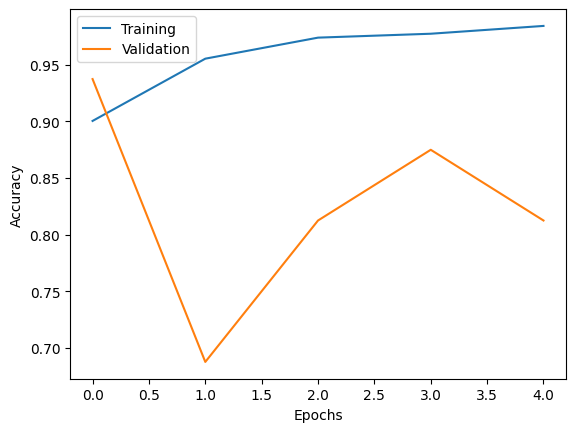

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])
plt.show()

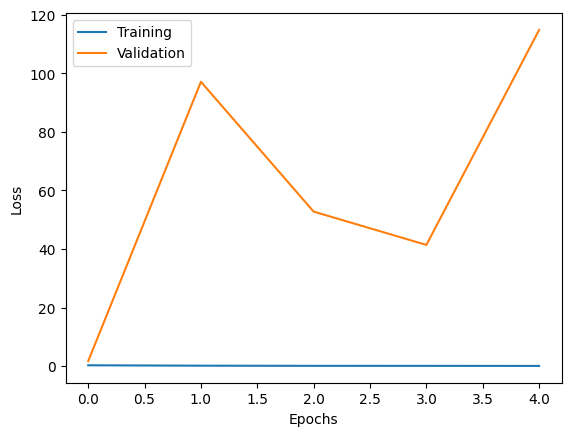

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.show()